Importing the Dependencies

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('insurance.csv')
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


Data Cleaning

In [10]:
df.shape

(1340, 10)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 104.8 KB


In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set(style = 'whitegrid', palette = 'Set2', font_scale = 1.1)
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [18]:
df.dropna(inplace = True) # as there are very few null values, we can drop them without losing much data
df.shape

(1332, 10)

In [20]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


EDA - Exploratory Data Analysis

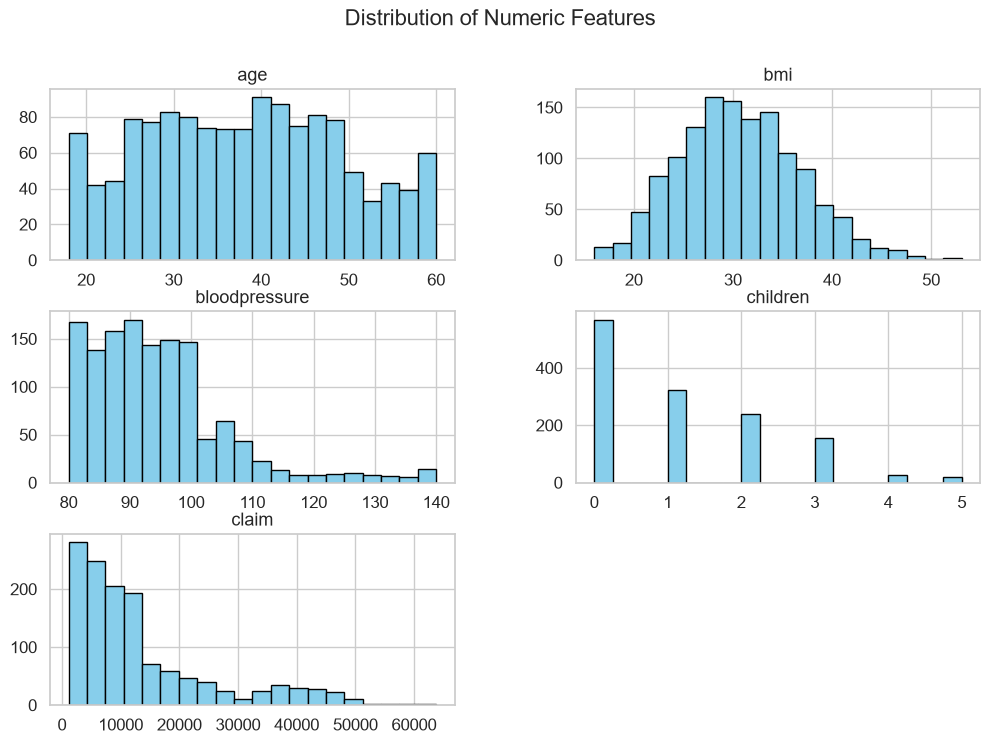

In [27]:
numeric_col = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[numeric_col].hist(bins = 20, figsize = (12, 8), color = 'skyblue', edgecolor = 'black')
plt.suptitle('Distribution of Numeric Features', fontsize = 16)
plt.show()

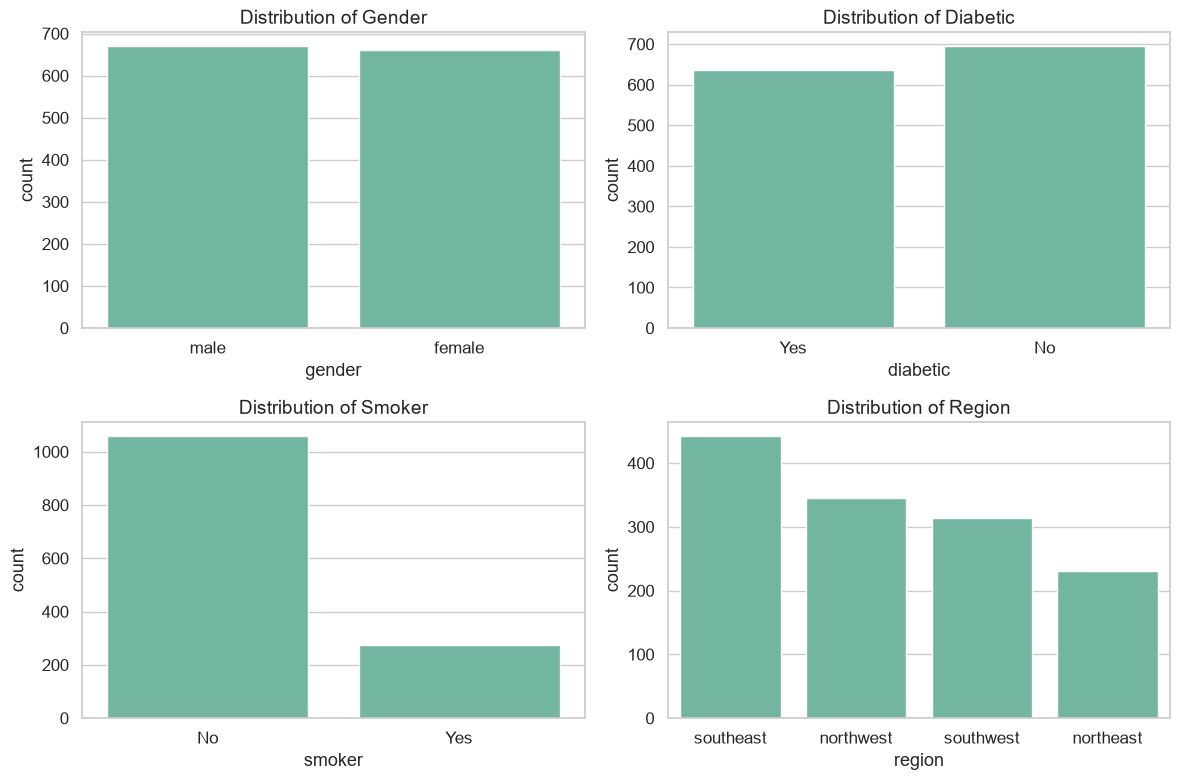

In [28]:
categorical_col = ['gender', 'diabetic', 'smoker', 'region']
plt.figure(figsize = (12, 8))

for i, col in enumerate(categorical_col, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data = df, x = col)
    plt.title(f'Distribution of {col.capitalize()}', fontsize = 14)

plt.tight_layout()
plt.show()
    

In [29]:
df.groupby(['gender', 'smoker'])['claim'].mean()

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

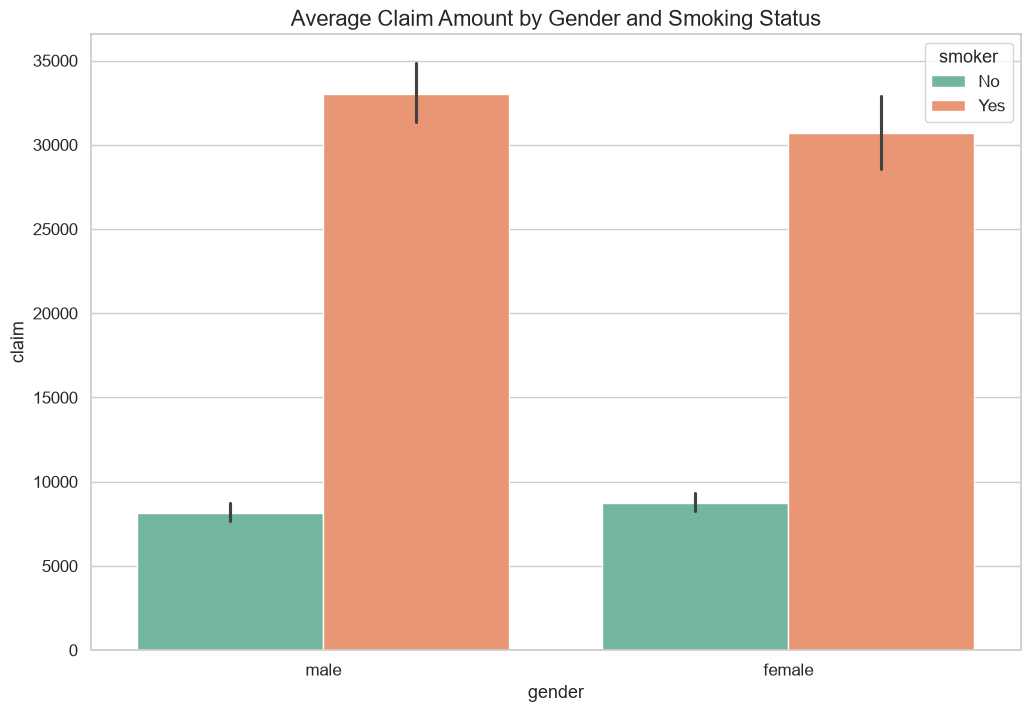

In [31]:
plt.figure(figsize = (12, 8))
sns.barplot(data = df, x = 'gender', y = 'claim', hue = 'smoker', estimator = np.mean)
plt.title('Average Claim Amount by Gender and Smoking Status', fontsize = 16)
plt.show()

In [32]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


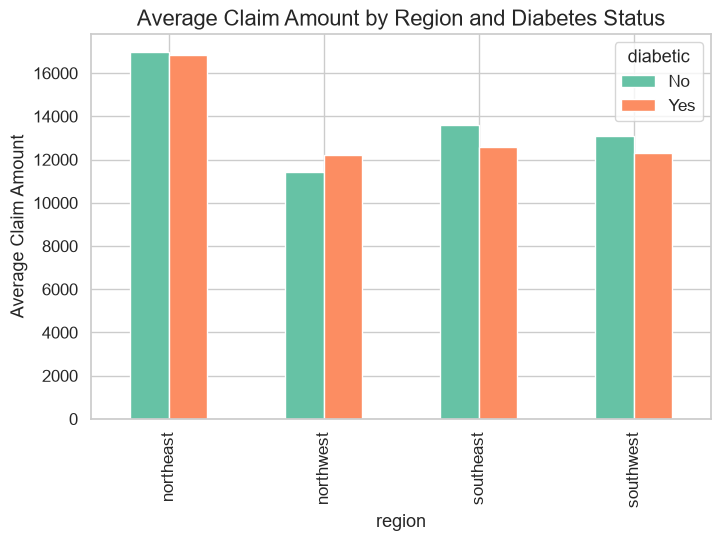

In [33]:
pivot_region_diabetic.plot(kind = 'bar', figsize = (8, 5))
plt.title('Average Claim Amount by Region and Diabetes Status', fontsize = 16)
plt.ylabel('Average Claim Amount')
plt.show()

In [34]:
pivot_table = df.pivot_table(values = 'claim', index = 'region', columns = 'smoker', aggfunc = np.mean)
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [35]:
pivot_table = df.pivot_table(values = 'claim', index = 'children', columns = 'diabetic', aggfunc = np.mean)
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


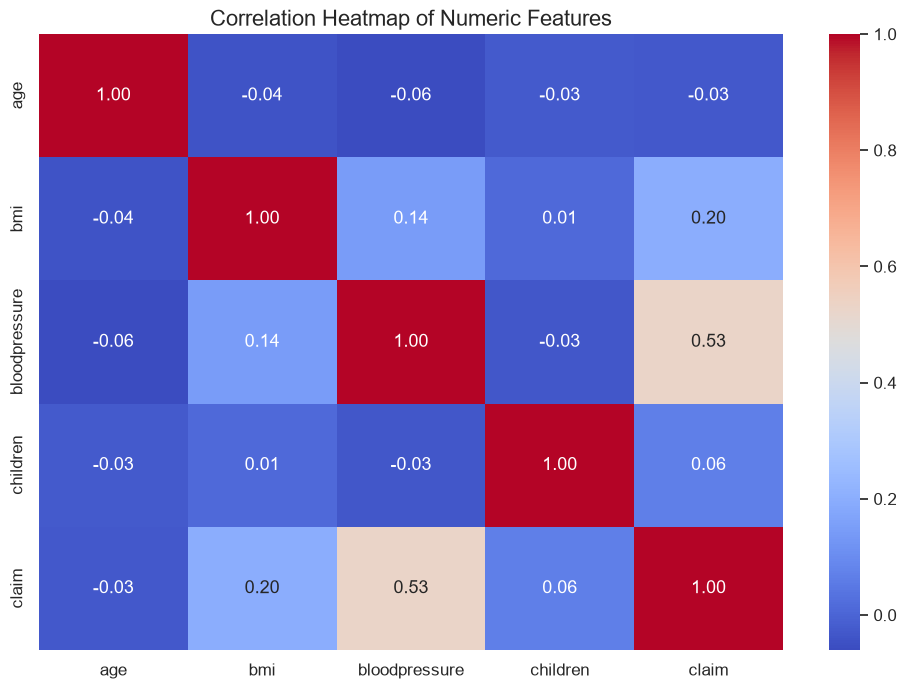

In [39]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[numeric_col].corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Heatmap of Numeric Features', fontsize = 16)
plt.show()

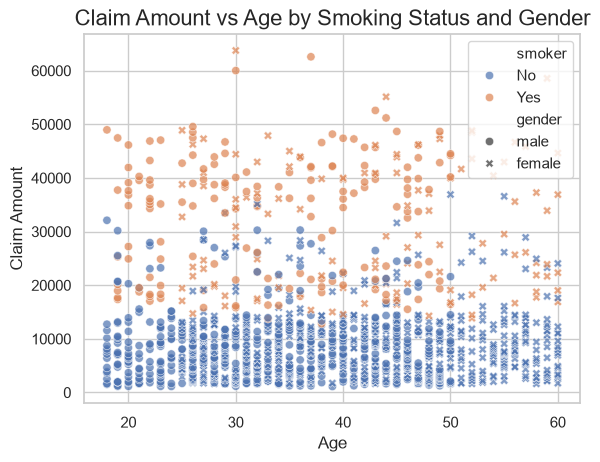

In [45]:
sns.scatterplot(data = df, x = 'age', y = 'claim', hue = 'smoker',  style = 'gender', alpha = 0.7)
plt.title('Claim Amount vs Age by Smoking Status and Gender', fontsize = 16)
plt.xlabel('Age')
plt.ylabel('Claim Amount')
plt.show()

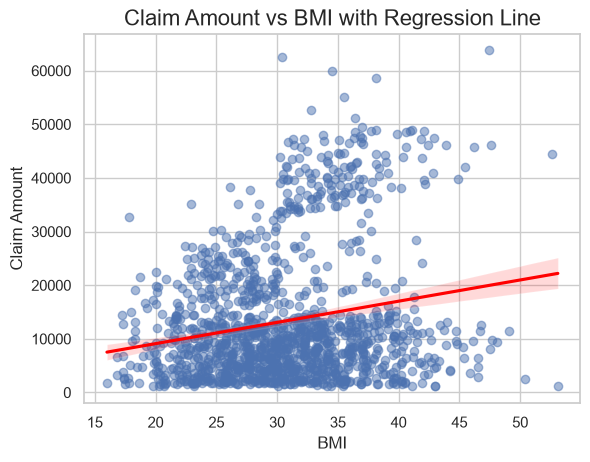

In [46]:
sns.regplot(data = df, x = 'bmi', y = 'claim', scatter_kws = {'alpha': 0.5}, line_kws = {'color': 'red'})
plt.title('Claim Amount vs BMI with Regression Line', fontsize = 16)
plt.xlabel('BMI')   
plt.ylabel('Claim Amount')
plt.show()

In [50]:
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 30, 45, 60, 100], labels = ['<18', '18-30', '31-45', '46-60', '60+'])
df['age_group'].value_counts()


age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

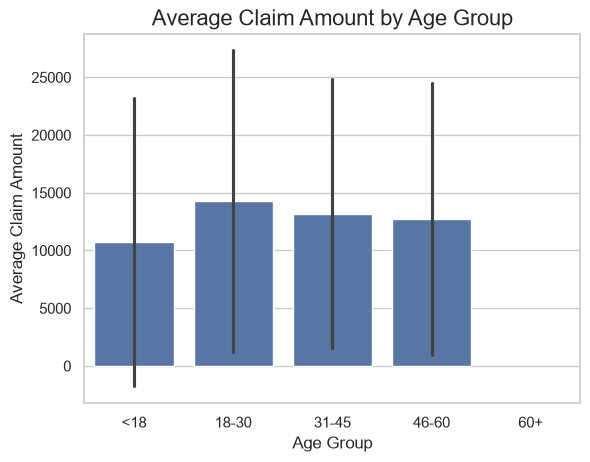

In [51]:
sns.barplot(data = df, x = 'age_group', y = 'claim', estimator = np.mean, errorbar = 'sd')
plt.title('Average Claim Amount by Age Group', fontsize = 16)
plt.xlabel('Age Group')     
plt.ylabel('Average Claim Amount')
plt.show()

In [52]:
df['bmi_category'] = pd.cut(df['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese'])
df['bmi_category'].value_counts()

bmi_category
Obese            702
Overweight       387
Normal weight    222
Underweight       21
Name: count, dtype: int64

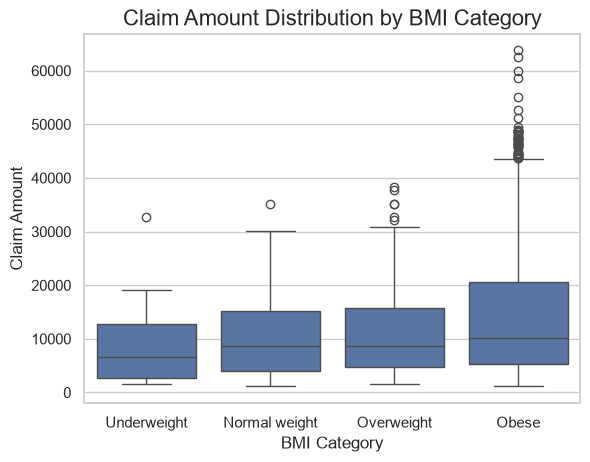

In [54]:
sns.boxplot(data = df, x = 'bmi_category', y = 'claim')
plt.title('Claim Amount Distribution by BMI Category', fontsize = 16)
plt.xlabel('BMI Category')
plt.ylabel('Claim Amount')
plt.show()